## Students

This report was prepared by the following students:

- **Student 1**: Abdulghani Almasri
- **Student 2**: Alvaro Garmendia

## Exercise 3.1

The result is:

## Matrix C
|0|1|2|3|4|
|-----|------|------|------|--------|
| 0.0 | 30.0 | 60.0 | 90.0 | 120.0 |
| 0.0 | 40.0 | 80.0 | 120.0 | 160.0 |
| 0.0 | 50.0 | 100.0 | 150.0 | 200.0 |
| 0.0 | 60.0 | 120.0 | 180.0 | 240.0 |
| 0.0 | 70.0 | 140.0 | 210.0 | 280.0 |


## Exercise 3.2

The performance results for increasing world sizes across 1, 2, and 4 nodes show that execution time increases as the number of processes grows. Consequently, the achieved speed-up remains below 1 in almost all cases, and efficiency drops rapidly. Ideally, increasing the number of processes should reduce execution time, resulting in speed-up > 1. However:

For 1 node, speed-up decreases from 0.99 (p=2) to 0.33 (p=24)
For 2 nodes, the best case is ~1.00 (p=2), after which it declines
For 4 nodes, speed-up never exceeds 1 and decreases steadily

This indicates that the parallel implementation does not provide performance benefits over the sequential version.

Efficiency drops sharply with increasing world size:

~50% at p=2
~10% or lower beyond p ≥ 8
approaches 0% for large p (e.g., 96 → 0.4%)

This behavior shows very poor scalability, especially for larger process counts. The main reason is that while work per process decreases, communication does not decrease proportionally, leading to a worse work-communication ratio. We have some plots below along with the code used to analyze the results.

| Nodes | World Size | Time [s] | Speed-up | Efficiency |
| ----: | ---------: | -------: | -------: | ---------: |
|     1 |          2 |   86.146 |    0.990 |      0.495 |
|     1 |          4 |   92.592 |    0.921 |      0.230 |
|     1 |          8 |  111.399 |    0.765 |      0.096 |
|     1 |         12 |  129.226 |    0.660 |      0.055 |
|     1 |         16 |  174.036 |    0.490 |      0.031 |
|     1 |         20 |  199.609 |    0.427 |      0.021 |
|     1 |         24 |  258.320 |    0.330 |      0.014 |
|     2 |          2 |   84.865 |    1.005 |      0.502 |
|     2 |          4 |   86.192 |    0.989 |      0.247 |
|     2 |         12 |   94.791 |    0.900 |      0.075 |
|     2 |         24 |  124.956 |    0.682 |      0.028 |
|     2 |         36 |  193.037 |    0.442 |      0.012 |
|     2 |         48 |  238.939 |    0.357 |      0.007 |
|     4 |          4 |   86.664 |    0.984 |      0.246 |
|     4 |         12 |   91.673 |    0.930 |      0.078 |
|     4 |         24 |   95.948 |    0.889 |      0.037 |
|     4 |         48 |  121.259 |    0.703 |      0.015 |
|     4 |         72 |  196.931 |    0.433 |      0.006 |
|     4 |         96 |  237.464 |    0.359 |      0.004 |


## Exercise 3.3

A clear trend is observed:

-For small matrices (≤ 512): GFLOP/s ≈ 0
-For medium matrices (1024–4096): Performance increases gradually
-For large matrices (8192–16384): Performance increases significantly, with peaks at: 91.6 GFLOP/s (12 ranks), 72.1 GFLOP/s (24 ranks)

Performance improves with increasing matrix size because computational cost scales as O(N³), communication scales much slower and larger problems increase the computation-to-communication ratio. 12 ranks outperforming 24 ranks shows that the introduced overhead trumps the additional parallelism. 

|  Size | Ranks | Time [s] | GFLOP/s |
| ----: | ----: | -------: | ------: |
|   128 |    12 |   97.428 |   0.000 |
|   128 |    24 |  120.247 |   0.000 |
|   256 |    12 |   98.823 |   0.000 |
|   256 |    24 |  122.468 |   0.000 |
|   512 |    12 |   94.980 |   0.003 |
|   512 |    24 |  119.822 |   0.002 |
|  1024 |    12 |   96.010 |   0.022 |
|  1024 |    24 |  124.251 |   0.017 |
|  2048 |    12 |   94.962 |   0.181 |
|  2048 |    24 |  124.015 |   0.139 |
|  4096 |    12 |   96.898 |   1.418 |
|  4096 |    24 |  122.876 |   1.119 |
|  8192 |    12 |   97.269 |  11.304 |
|  8192 |    24 |  121.485 |   9.051 |
| 16384 |    12 |   96.050 |  91.578 |
| 16384 |    24 |  121.957 |  72.125 |


Sequential time: 85.2656 s

Nodes | World Size | Time [s] | Speed-up | Efficiency
------------------------------------------------------
    1 |          2 |   86.146 |    0.990 |      0.495
    1 |          4 |   92.592 |    0.921 |      0.230
    1 |          8 |  111.399 |    0.765 |      0.096
    1 |         12 |  129.226 |    0.660 |      0.055
    1 |         16 |  174.036 |    0.490 |      0.031
    1 |         20 |  199.609 |    0.427 |      0.021
    1 |         24 |  258.320 |    0.330 |      0.014
    2 |          2 |   84.865 |    1.005 |      0.502
    2 |          4 |   86.192 |    0.989 |      0.247
    2 |         12 |   94.791 |    0.900 |      0.075
    2 |         24 |  124.956 |    0.682 |      0.028
    2 |         36 |  193.037 |    0.442 |      0.012
    2 |         48 |  238.939 |    0.357 |      0.007
    4 |          4 |   86.664 |    0.984 |      0.246
    4 |         12 |   91.673 |    0.930 |      0.078
    4 |         24 |   95.948 |    0.889 |      0.037

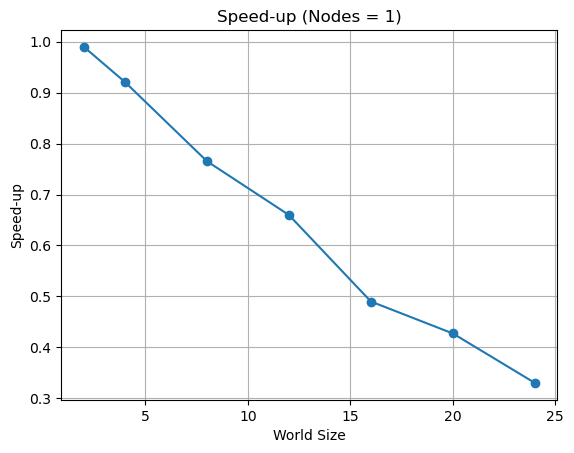

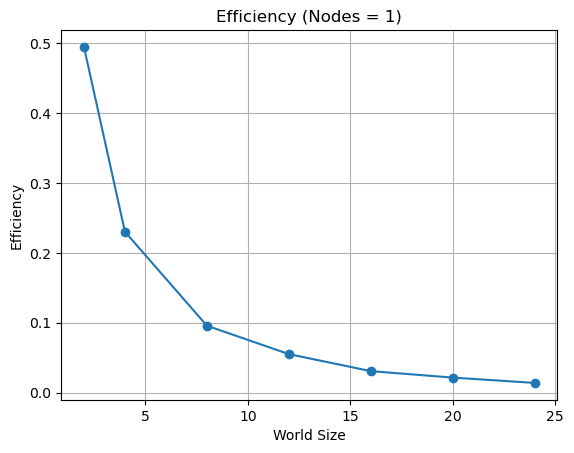

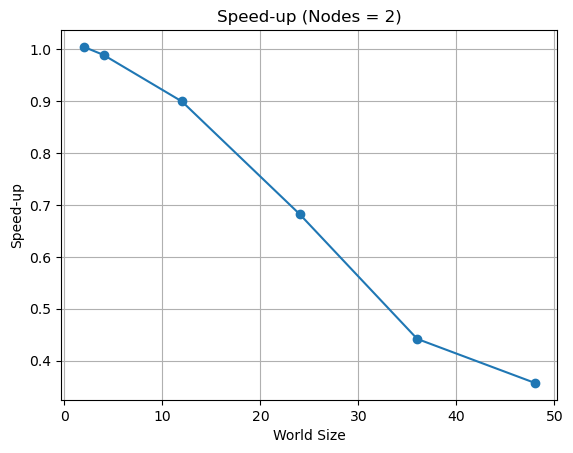

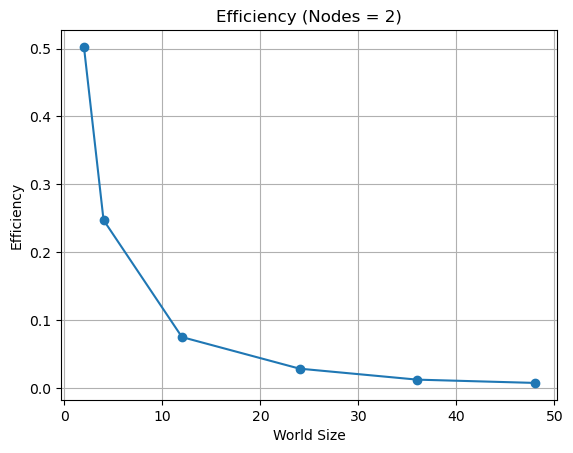

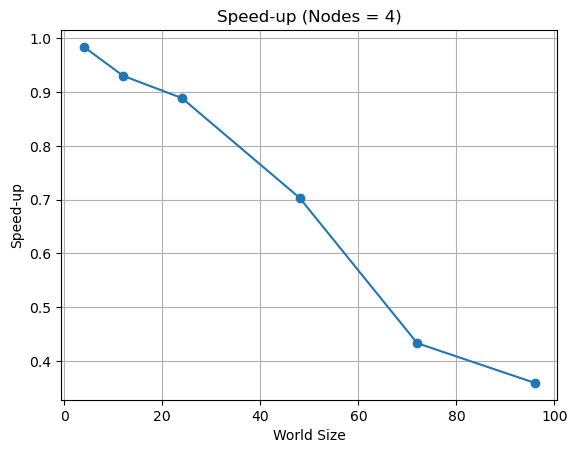

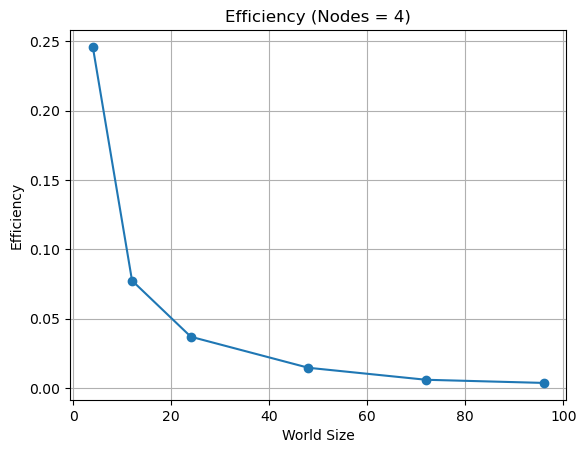

In [2]:
import os
import re
import numpy as np
import matplotlib.pyplot as plt

# --- CONFIG ---
seq_file = "seq.txt"

# --- FUNCTIONS ---
def extract_times(filename):
    times = []
    with open(filename, "r") as f:
        for line in f:
            if "Execution time" in line:
                t = float(line.split(":")[1].strip().split()[0])
                times.append(t)
    return times

def parse_filename(name):
    # node<n>_p<m>.txt
    match = re.match(r'node(\d+)_p(\d+)\.txt', name)
    if match:
        return int(match.group(1)), int(match.group(2))
    return None, None

# --- SEQUENTIAL BASELINE ---
seq_times = extract_times(seq_file)
seq_time = np.mean(seq_times)
print(f"Sequential time: {seq_time:.4f} s\n")

# --- COLLECT DATA ---
results = []

for file in os.listdir():
    if file.startswith("node") and file.endswith(".txt"):
        nodes, p = parse_filename(file)
        times = extract_times(file)

        if times:
            avg_time = np.mean(times)
            speedup = seq_time / avg_time
            efficiency = speedup / p

            results.append((nodes, p, avg_time, speedup, efficiency))

# sort nicely
results.sort(key=lambda x: (x[0], x[1]))

# --- PRINT TABLE ---
print("Nodes | World Size | Time [s] | Speed-up | Efficiency")
print("------------------------------------------------------")
for r in results:
    print(f"{r[0]:5d} | {r[1]:10d} | {r[2]:8.3f} | {r[3]:8.3f} | {r[4]:10.3f}")

# --- PLOTS ---
nodes_set = sorted(set(r[0] for r in results))

for nodes in nodes_set:
    subset = [r for r in results if r[0] == nodes]
    p_vals = [r[1] for r in subset]
    speedups = [r[3] for r in subset]
    efficiencies = [r[4] for r in subset]

    plt.figure()
    plt.plot(p_vals, speedups, marker='o')
    plt.xlabel("World Size")
    plt.ylabel("Speed-up")
    plt.title(f"Speed-up (Nodes = {nodes})")
    plt.grid()
    plt.savefig(f"speedup_nodes{nodes}.png")

    plt.figure()
    plt.plot(p_vals, efficiencies, marker='o')
    plt.xlabel("World Size")
    plt.ylabel("Efficiency")
    plt.title(f"Efficiency (Nodes = {nodes})")
    plt.grid()
    plt.savefig(f"efficiency_nodes{nodes}.png")

print("\nPlots saved as PNG files.")

## Exercise 3.3

Size | Ranks | Time [s] | GFLOP/s
-----------------------------------
  128 |    12 |   97.428 |      0.000
  128 |    24 |  120.247 |      0.000
  256 |    12 |   98.823 |      0.000
  256 |    24 |  122.468 |      0.000
  512 |    12 |   94.980 |      0.003
  512 |    24 |  119.822 |      0.002
 1024 |    12 |   96.010 |      0.022
 1024 |    24 |  124.251 |      0.017
 2048 |    12 |   94.962 |      0.181
 2048 |    24 |  124.015 |      0.139
 4096 |    12 |   96.898 |      1.418
 4096 |    24 |  122.876 |      1.119
 8192 |    12 |   97.269 |     11.304
 8192 |    24 |  121.485 |      9.051
16384 |    12 |   96.050 |     91.578
16384 |    24 |  121.957 |     72.125

Plots saved.


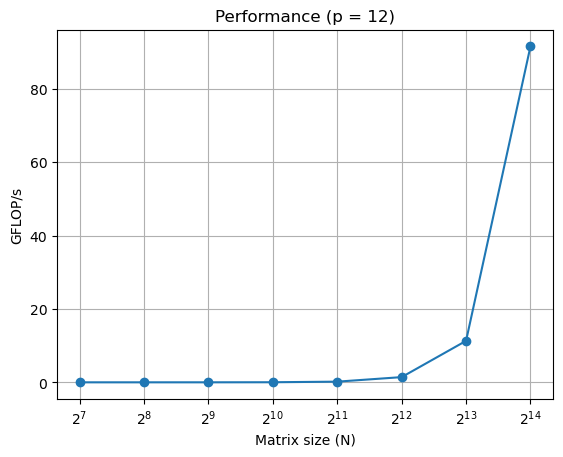

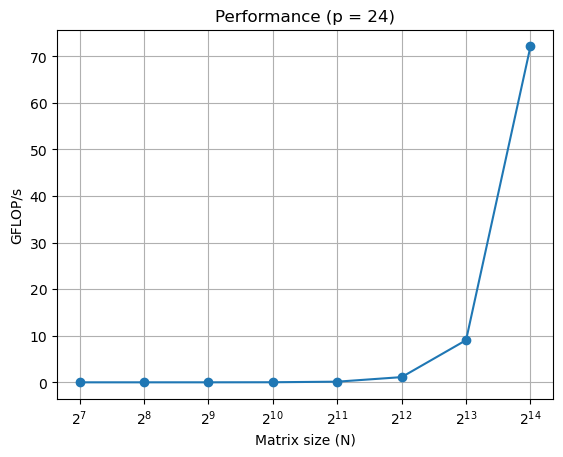

In [3]:
import os
import re
import numpy as np
import matplotlib.pyplot as plt

def extract_time(filename):
    with open(filename) as f:
        for line in f:
            if "Execution time" in line:
                return float(line.split(":")[1].split()[0])
    return None

def parse_filename(name):
    # size<n>_p<m>.txt
    m = re.match(r'size(\d+)_p(\d+)\.txt', name)
    if m:
        return int(m.group(1)), int(m.group(2))
    return None, None

results = []

for file in os.listdir():
    if file.startswith("size"):
        n, p = parse_filename(file)
        t = extract_time(file)

        if t:
            flops = 2 * (n**3)
            gflops = flops / t / 1e9
            results.append((n, p, t, gflops))

results.sort()

# print table
print("Size | Ranks | Time [s] | GFLOP/s")
print("-----------------------------------")
for r in results:
    print(f"{r[0]:5d} | {r[1]:5d} | {r[2]:8.3f} | {r[3]:10.3f}")

# plot
for p in [12, 24]:
    subset = [r for r in results if r[1] == p]
    sizes = [r[0] for r in subset]
    gflops = [r[3] for r in subset]

    plt.figure()
    plt.plot(sizes, gflops, marker='o')
    plt.xscale("log", base=2)
    plt.xlabel("Matrix size (N)")
    plt.ylabel("GFLOP/s")
    plt.title(f"Performance (p = {p})")
    plt.grid()
    plt.savefig(f"gflops_p{p}.png")

print("\nPlots saved.")

## Exercise 3.4 Willingness to present

- Matrix multiply - parallel version using MPI (Section: 3.1)
- Matrix multiply - scaling ranks (Section: 3.2)
- Matrix multiply - scaling problem size (Section: 3.3)